# Prediksi - LSTM

Oleh
- CHRISTINA DEWI - 20925002
- ULYA HALIMAH - 20925008
- SUSI KOMALASARI - 20925009
- ILMANIA SYAKIRA - 10222118

## 1. Import Library

In [ ]:
import os
import json
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(2)

print('Torch  :', torch.__version__)
print('Pandas :', pd.__version__)
print('NumPy  :', np.__version__)


Torch  : 2.11.0+cpu
Pandas : 2.2.2
NumPy  : 2.0.2


## 2. Konfigurasi

In [ ]:
# CONFIG
CSV_PATH   = r'data_stock_prices.csv'
OUTPUT_DIR = Path(r'lstm_global_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_END = pd.Timestamp('2024-01-01')
VALID_END = pd.Timestamp('2025-01-01')

LSTM_CONFIGS = [
    {'seq_len': 10, 'hidden': 32,  'layers': 1, 'dropout': 0.10, 'lr': 1e-3},
    {'seq_len': 20, 'hidden': 32,  'layers': 1, 'dropout': 0.10, 'lr': 1e-3},
    {'seq_len': 30, 'hidden': 48,  'layers': 1, 'dropout': 0.10, 'lr': 8e-4},
    {'seq_len': 30, 'hidden': 64,  'layers': 2, 'dropout': 0.15, 'lr': 8e-4},
]

MAX_EPOCHS   = 60
PATIENCE     = 10
BATCH_SIZE   = 128
WEIGHT_DECAY = 1e-4
ALPHA_GRID = np.round(np.linspace(0.5, 1.5, 41), 3)

TARGET_R2   = 0.90
TARGET_MAPE = 10.0
AUX_TARGET_DA = 55.0

print('Output dir      :', OUTPUT_DIR)
print('Alpha grid      : [{:.2f}, {:.2f}] — {}  nilai'.format(
    ALPHA_GRID[0], ALPHA_GRID[-1], len(ALPHA_GRID)))
print('Primary metrics : R2, MAE (USD), RMSE (USD), MAPE (%)')
print('Auxiliary       : Directional Accuracy, Beat Naive Rate')


Output dir      : lstm_global_outputs
Alpha grid      : [0.50, 1.50] — 41  nilai
Primary metrics : R2, MAE (USD), RMSE (USD), MAPE (%)
Auxiliary       : Directional Accuracy, Beat Naive Rate


## 3. Load & Audit Data

In [ ]:
# LOAD & AUDIT DATA
df = pd.read_csv(CSV_PATH, parse_dates=['Date'])
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

print('Shape     :', df.shape)
print('Periode   :', df['Date'].min().date(), '->', df['Date'].max().date())
print('Tickers   :', sorted(df['Ticker'].unique()))
print('Rows/ticker:')
print(df.groupby('Ticker').size())

audit = {
    'shape'                  : list(df.shape),
    'date_min'               : str(df['Date'].min().date()),
    'date_max'               : str(df['Date'].max().date()),
    'tickers'                : sorted(df['Ticker'].unique().tolist()),
    'missing_total'          : int(df.isna().sum().sum()),
    'duplicate_ticker_date'  : int(df.duplicated(['Ticker','Date']).sum()),
    'bad_high_rows'          : int((df['High'] < df[['Open','Close','Low']].max(axis=1)).sum()),
    'bad_low_rows'           : int((df['Low']  > df[['Open','Close','High']].min(axis=1)).sum()),
    'zero_volume_rows'       : int((df['Volume'] == 0).sum()),
}
print(json.dumps(audit, indent=2))


Shape     : (14964, 19)
Periode   : 2016-02-23 -> 2026-01-22
Tickers   : ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA']
Rows/ticker:
Ticker
AAPL     2494
AMZN     2494
GOOGL    2494
META     2494
MSFT     2494
NVDA     2494
dtype: int64
{
  "shape": [
    14964,
    19
  ],
  "date_min": "2016-02-23",
  "date_max": "2026-01-22",
  "tickers": [
    "AAPL",
    "AMZN",
    "GOOGL",
    "META",
    "MSFT",
    "NVDA"
  ],
  "missing_total": 0,
  "duplicate_ticker_date": 0,
  "bad_high_rows": 0,
  "bad_low_rows": 0,
  "zero_volume_rows": 0
}


## 4. Feature Engineering

In [ ]:
# FEATURE ENGINEERING
df['Target_Next_Day_Close']  = df['Next_Day_Close'].astype(float)
df['Target_Next_Day_Return'] = df['Target_Next_Day_Close'] / df['Close'] - 1.0
df['Next_Date_In_File']      = df.groupby('Ticker')['Date'].shift(-1)

# Fitur relatif (menggantikan raw price yang redundan)
df['OC_Return']          = (df['Close'] - df['Open']) / df['Open']
df['HL_Range']           = (df['High'] - df['Low']) / df['Close']
df['Close_vs_SMA7']      = df['Close'] / df['SMA_7']  - 1
df['Close_vs_SMA21']     = df['Close'] / df['SMA_21'] - 1
df['Close_vs_EMA12']     = df['Close'] / df['EMA_12'] - 1
df['Close_vs_EMA26']     = df['Close'] / df['EMA_26'] - 1
df['SMA7_vs_SMA21']      = df['SMA_7']  / df['SMA_21'] - 1
df['EMA12_vs_EMA26']     = df['EMA_12'] / df['EMA_26'] - 1
df['MACD_Histogram']     = df['MACD'] - df['MACD_Signal']
df['MACD_norm']          = df['MACD']        / df['Close']
df['MACD_signal_norm']   = df['MACD_Signal'] / df['Close']
df['Bollinger_Width']    = (df['Bollinger_Upper'] - df['Bollinger_Lower']) / df['Close']
df['Bollinger_Pos']      = (df['Close'] - df['Bollinger_Lower']) / (
                            df['Bollinger_Upper'] - df['Bollinger_Lower'])
df['RSI_14_norm']        = df['RSI_14'] / 100.0
df['LogVolume']          = np.log1p(df['Volume'])

# Fitur rank & relative strength
df['Close_Rank_252']  = df.groupby('Ticker')['Close'].transform(
    lambda s: s.rolling(252, min_periods=60).rank(pct=True))
df['Volume_Rank_252'] = df.groupby('Ticker')['Volume'].transform(
    lambda s: s.rolling(252, min_periods=60).rank(pct=True))
market_return = df.groupby('Date')['Daily_Return'].mean().rename('Market_Return')
df = df.merge(market_return, on='Date', how='left')
df['Relative_Strength'] = df['Daily_Return'] - df['Market_Return']

# Lag & rolling return (hanya melihat ke belakang)
for lag in [1, 2, 3, 5, 10]:
    df[f'Return_lag_{lag}'] = df.groupby('Ticker')['Daily_Return'].shift(lag)

for win in [5, 10, 21]:
    df[f'Return_mean_{win}']  = df.groupby('Ticker')['Daily_Return'].transform(
        lambda s: s.rolling(win, min_periods=win).mean())
    df[f'Return_std_{win}']   = df.groupby('Ticker')['Daily_Return'].transform(
        lambda s: s.rolling(win, min_periods=win).std())
    df[f'Volume_mean_{win}']  = df.groupby('Ticker')['LogVolume'].transform(
        lambda s: s.rolling(win, min_periods=win).mean())

# Tambahan: Volatility relatif
df['Volatility_norm'] = df['Volatility_7d'] / df['Close']

base_features = [
    # Momentum & posisi harga (relatif, bukan absolut)
    'OC_Return', 'HL_Range',
    'Close_vs_SMA7', 'Close_vs_SMA21', 'Close_vs_EMA12', 'Close_vs_EMA26',
    'SMA7_vs_SMA21', 'EMA12_vs_EMA26',
    # Oscillator & tren (sudah ternormalisasi)
    'RSI_14_norm',
    'MACD_Histogram', 'MACD_norm', 'MACD_signal_norm',
    # Volatilitas
    'Bollinger_Width', 'Bollinger_Pos', 'Volatility_norm',
    # Volume
    'LogVolume',
    # Rank & relative (tidak bias skala harga)
    'Close_Rank_252', 'Volume_Rank_252', 'Relative_Strength',
    # Daily return raw
    'Daily_Return',
    # Lag features
    'Return_lag_1', 'Return_lag_2', 'Return_lag_3', 'Return_lag_5', 'Return_lag_10',
    # Rolling aggregates
    'Return_mean_5', 'Return_mean_10', 'Return_mean_21',
    'Return_std_5',  'Return_std_10',  'Return_std_21',
    'Volume_mean_5', 'Volume_mean_10', 'Volume_mean_21',
]

work = df.replace([np.inf, -np.inf], np.nan).dropna(
    subset=base_features + ['Target_Next_Day_Return']).copy()

# One-hot ticker
ticker_dummies = pd.get_dummies(work['Ticker'], prefix='Ticker').astype(float)
work = pd.concat([work.reset_index(drop=True), ticker_dummies.reset_index(drop=True)], axis=1)
feature_cols = base_features + ticker_dummies.columns.tolist()

train_mask = work['Date'] < TRAIN_END
valid_mask = (work['Date'] >= TRAIN_END) & (work['Date'] < VALID_END)
test_mask  = work['Date'] >= VALID_END

print('Rows after FE   :', len(work))
print('Features        :', len(feature_cols),
      f'  (raw={len(base_features)}, ticker_dummies={len(ticker_dummies.columns)})')
print('Train/Valid/Test:', train_mask.sum(), valid_mask.sum(), test_mask.sum())
print('Target training : Target_Next_Day_Return')
print('Output akhir    : Pred_Next_Day_Close = Close * (1 + alpha * Pred_Return)')


Rows after FE   : 14610
Features        : 40   (raw=34, ticker_dummies=6)
Train/Valid/Test: 11514 1512 1584
Target training : Target_Next_Day_Return
Output akhir    : Pred_Next_Day_Close = Close * (1 + alpha * Pred_Return)


## 5. Scaling - Fit Hanya pada Train

In [ ]:
# SCALING
scaler_X = StandardScaler().fit(work.loc[train_mask, feature_cols])
scaler_y = StandardScaler().fit(work.loc[train_mask, ['Target_Next_Day_Return']])

scaled = work.copy()
scaled['Raw_Close']                  = work['Close'].values
scaled['Raw_Target_Next_Day_Close']  = work['Target_Next_Day_Close'].values
scaled['Raw_Target_Next_Day_Return'] = work['Target_Next_Day_Return'].values
scaled['Raw_Daily_Return']           = work['Daily_Return'].values

scaled[feature_cols] = scaler_X.transform(work[feature_cols])
scaled['y_scaled']   = scaler_y.transform(work[['Target_Next_Day_Return']])[:, 0]

print('Scaler fit hanya train: OK')
print(f'  X_train shape : {work.loc[train_mask, feature_cols].shape}')
print(f'  y_train shape : {work.loc[train_mask, ["Target_Next_Day_Return"]].shape}')


Scaler fit hanya train: OK
  X_train shape : (11514, 40)
  y_train shape : (11514, 1)


## 6. Sequence Builder & Model LSTM

In [ ]:
# SEQUENCE BUILDER
def build_sequences(df_scaled, feature_cols, seq_len):
    Xs, ys, rows = [], [], []
    for ticker, g in df_scaled.groupby('Ticker', sort=False):
        g  = g.sort_values('Date').reset_index(drop=True)
        Xv = g[feature_cols].values.astype(np.float32)
        yv = g['y_scaled'].values.astype(np.float32)
        for i in range(seq_len - 1, len(g)):
            Xs.append(Xv[i-seq_len+1:i+1])
            ys.append(yv[i])
            rows.append({
                'Date'          : g.loc[i, 'Date'],
                'Ticker'        : ticker,
                'Close'         : g.loc[i, 'Raw_Close'],
                'Actual'        : g.loc[i, 'Raw_Target_Next_Day_Close'],
                'Actual_Return' : g.loc[i, 'Raw_Target_Next_Day_Return'],
                'Daily_Return'  : g.loc[i, 'Raw_Daily_Return'],
            })
    return np.stack(Xs), np.array(ys, dtype=np.float32), pd.DataFrame(rows)

# MODEL LSTM
class LSTMRegressor(nn.Module):
    def __init__(self, n_features, hidden=32, layers=1, dropout=0.10):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden,
            num_layers=layers,
            batch_first=True,
            dropout=dropout if layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.LayerNorm(hidden),
            nn.Linear(hidden, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        # LSTM mengembalikan (output, (h_n, c_n))
        # Ambil h_n layer terakhir sebagai representasi sequence
        _, (h, _) = self.lstm(x)
        return self.head(h[-1]).squeeze(-1)


def make_loader(X, y, mask, batch_size, shuffle):
    idx = np.where(mask.values)[0]
    ds  = TensorDataset(
        torch.tensor(X[idx], dtype=torch.float32),
        torch.tensor(y[idx], dtype=torch.float32)
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


print('LSTMRegressor siap.')
# Preview arsitektur
_m = LSTMRegressor(n_features=len(feature_cols), hidden=64, layers=2, dropout=0.15)
total_params = sum(p.numel() for p in _m.parameters())
print(f'Contoh LSTM(hidden=64, layers=2) — total params: {total_params:,}')
del _m

LSTMRegressor siap.
Contoh LSTM(hidden=64, layers=2) — total params: 62,657


## 7. Fungsi Metrik

In [ ]:
# METRICS
def calc_metrics(meta, pred_close):
    actual = meta['Actual'].values
    close  = meta['Close'].values
    pred   = np.asarray(pred_close)
    naive  = close  # naive baseline: harga besok = harga hari ini
    out = {
        'R2'                       : r2_score(actual, pred),
        'R2_Naive'                 : r2_score(actual, naive),
        'MAE'                      : mean_absolute_error(actual, pred),
        'MAE_Naive'                : mean_absolute_error(actual, naive),
        'RMSE'                     : math.sqrt(mean_squared_error(actual, pred)),
        'RMSE_Naive'               : math.sqrt(mean_squared_error(actual, naive)),
        'MAPE_%'                   : np.mean(np.abs((actual - pred)  / np.maximum(np.abs(actual), 1e-9))) * 100,
        'MAPE_Naive_%'             : np.mean(np.abs((actual - naive) / np.maximum(np.abs(actual), 1e-9))) * 100,
        'Directional_Accuracy_%'   : np.mean(((pred  - close) > 0) == ((actual - close) > 0)) * 100,
        'Naive_DA_%'               : np.mean(((naive - close) > 0) == ((actual - close) > 0)) * 100,
        'Beat_Naive_Rate_%'        : np.mean(np.abs(actual - pred) < np.abs(actual - naive)) * 100,
    }
    out['R2_Better_Than_Naive']   = out['R2']   > out['R2_Naive']
    out['MAE_Better_Than_Naive']  = out['MAE']  < out['MAE_Naive']
    out['RMSE_Better_Than_Naive'] = out['RMSE'] < out['RMSE_Naive']
    return out


def metrics_by_ticker(meta, pred_close):
    tmp = meta.copy()
    tmp['Predicted'] = pred_close
    rows = [{'Ticker': 'ALL', **calc_metrics(tmp, tmp['Predicted'].values), 'n': len(tmp)}]
    for ticker, g in tmp.groupby('Ticker'):
        rows.append({'Ticker': ticker, **calc_metrics(g, g['Predicted'].values), 'n': len(g)})
    return pd.DataFrame(rows)


def choose_alpha_on_validation(valid_meta, pred_return_raw):
    """
    Pilih alpha dari validation saja — tidak menyentuh test set (anti-leakage).
    PERBAIKAN: ALPHA_GRID [0.5, 1.5] menghindari nilai negatif atau >2
    yang tidak bermakna secara finansial.
    """
    best = None
    for alpha in ALPHA_GRID:
        pred_close = valid_meta['Close'].values * (1.0 + alpha * pred_return_raw)
        m   = calc_metrics(valid_meta, pred_close)
        key = (m['RMSE'], m['MAPE_%'], -m['R2'])
        if best is None or key < best['key']:
            best = {'alpha': float(alpha), 'metrics': m, 'key': key}
    return best['alpha'], best['metrics']


print('Fungsi metrik siap.')
print('Catatan: MAE & RMSE dalam satuan USD (harga asli setelah inverse transform alpha)')


Fungsi metrik siap.
Catatan: MAE & RMSE dalam satuan USD (harga asli setelah inverse transform alpha)


## 8. Fungsi Train Satu Konfigurasi

In [ ]:
# TRAIN ONE CONFIG
def train_one_config(cfg):
    seq_len = cfg['seq_len']
    X, y, meta = build_sequences(scaled, feature_cols, seq_len)

    m_train = meta['Date'] < TRAIN_END
    m_valid = (meta['Date'] >= TRAIN_END) & (meta['Date'] < VALID_END)
    m_test  = meta['Date'] >= VALID_END

    train_loader = make_loader(X, y, m_train, BATCH_SIZE, True)
    valid_loader = make_loader(X, y, m_valid, BATCH_SIZE, False)

    model   = LSTMRegressor(X.shape[-1], hidden=cfg['hidden'],
                             layers=cfg['layers'], dropout=cfg['dropout'])
    opt     = torch.optim.AdamW(model.parameters(), lr=cfg['lr'],
                                weight_decay=WEIGHT_DECAY)
    loss_fn = nn.SmoothL1Loss()

    best_state, best_val, stale = None, float('inf'), 0
    history = []

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        tr_sum, tr_n = 0.0, 0
        for xb, yb in train_loader:
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tr_sum += loss.item() * len(yb); tr_n += len(yb)

        model.eval()
        vl_sum, vl_n = 0.0, 0
        with torch.no_grad():
            for xb, yb in valid_loader:
                loss = loss_fn(model(xb), yb)
                vl_sum += loss.item() * len(yb); vl_n += len(yb)

        tl = tr_sum / max(tr_n, 1)
        vl = vl_sum / max(vl_n, 1)
        history.append({'epoch': epoch, 'train_loss': tl, 'valid_loss': vl})

        if vl < best_val - 1e-6:
            best_val = vl; stale = 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            stale += 1
        if stale >= PATIENCE:
            break

    model.load_state_dict(best_state)

    def predict_return(mask):
        idx  = np.where(mask.values)[0]
        outs = []
        model.eval()
        with torch.no_grad():
            for s in range(0, len(idx), 512):
                xb = torch.tensor(X[idx[s:s+512]], dtype=torch.float32)
                outs.append(model(xb).numpy())
        pred_sc     = np.concatenate(outs)
        pred_return = scaler_y.inverse_transform(pred_sc.reshape(-1,1))[:,0]
        return meta.iloc[idx].reset_index(drop=True), pred_return

    valid_meta, valid_pred_ret = predict_return(m_valid)
    test_meta,  test_pred_ret  = predict_return(m_test)

    alpha, alpha_valid_metrics = choose_alpha_on_validation(valid_meta, valid_pred_ret)

    valid_pred_close = valid_meta['Close'].values * (1.0 + alpha * valid_pred_ret)
    test_pred_close  = test_meta['Close'].values  * (1.0 + alpha * test_pred_ret)

    valid_metrics = calc_metrics(valid_meta, valid_pred_close)
    test_metrics  = calc_metrics(test_meta,  test_pred_close)

    result = {
        **cfg,
        'epochs'               : len(history),
        'best_valid_loss_scaled': best_val,
        'alpha'                : alpha,
        **{f'valid_{k}': v for k, v in valid_metrics.items()},
        **{f'test_{k}' : v for k, v in test_metrics.items()},
    }

    detail = test_meta.copy()
    detail['Pred_Return_Raw'] = test_pred_ret
    detail['Alpha']           = alpha
    detail['Pred_Return']     = alpha * test_pred_ret
    detail['Predicted']       = test_pred_close
    detail['Naive']           = detail['Close']
    detail['Residual']        = detail['Actual'] - detail['Predicted']
    detail['APE_%']           = np.abs(detail['Residual'] / detail['Actual']) * 100
    detail['Dir_Correct']     = (
        ((detail['Actual'] - detail['Close']) > 0) ==
        ((detail['Predicted'] - detail['Close']) > 0)
    )
    detail['Beat_Naive'] = (
        np.abs(detail['Actual'] - detail['Predicted']) <
        np.abs(detail['Actual'] - detail['Naive'])
    )
    return result, detail, pd.DataFrame(history)

## 9. Jalankan Semua Konfigurasi

In [ ]:
# RUN EXPERIMENTS
all_results = []
best = None

for cfg in LSTM_CONFIGS:
    print('Training config:', cfg)
    result, detail, history = train_one_config(cfg)
    all_results.append(result)
    print(
        f"  valid  R2={result['valid_R2']:.4f} | RMSE=${result['valid_RMSE']:.4f} | "
        f"DA={result['valid_Directional_Accuracy_%']:.2f}% | alpha={result['alpha']:.3f}"
    )
    print(
        f"  test   R2={result['test_R2']:.4f} | RMSE=${result['test_RMSE']:.4f} | "
        f"DA={result['test_Directional_Accuracy_%']:.2f}% | beat naive={result['test_Beat_Naive_Rate_%']:.2f}%"
    )
    key = (result['valid_RMSE'], result['valid_MAPE_%'], -result['valid_R2'])
    if best is None or key < best['key']:
        best = {'key': key, 'result': result, 'detail': detail, 'history': history}

results_df = pd.DataFrame(all_results).sort_values('valid_RMSE').reset_index(drop=True)
results_df.to_excel(OUTPUT_DIR / 'lstm_global_model_selection.xlsx', index=False)

print('\nMODEL SELECTION (urut valid_RMSE terkecil):')
display(results_df[[
    'seq_len','hidden','layers','epochs','alpha',
    'valid_R2','valid_RMSE','valid_MAE','valid_MAPE_%','valid_Directional_Accuracy_%',
    'test_R2','test_RMSE','test_MAE','test_MAPE_%','test_Directional_Accuracy_%','test_Beat_Naive_Rate_%',
]].round(4))


Training config: {'seq_len': 10, 'hidden': 32, 'layers': 1, 'dropout': 0.1, 'lr': 0.001}
  valid  R2=0.9986 | RMSE=$5.5505 | DA=53.77% | alpha=0.625
  test   R2=0.9984 | RMSE=$7.5519 | DA=52.97% | beat naive=51.33%
Training config: {'seq_len': 20, 'hidden': 32, 'layers': 1, 'dropout': 0.1, 'lr': 0.001}
  valid  R2=0.9986 | RMSE=$5.5608 | DA=53.44% | alpha=0.500
  test   R2=0.9984 | RMSE=$7.5582 | DA=52.02% | beat naive=50.57%
Training config: {'seq_len': 30, 'hidden': 48, 'layers': 1, 'dropout': 0.1, 'lr': 0.0008}
  valid  R2=0.9986 | RMSE=$5.5701 | DA=54.70% | alpha=0.500
  test   R2=0.9984 | RMSE=$7.5224 | DA=52.65% | beat naive=51.64%
Training config: {'seq_len': 30, 'hidden': 64, 'layers': 2, 'dropout': 0.15, 'lr': 0.0008}
  valid  R2=0.9986 | RMSE=$5.5468 | DA=55.29% | alpha=0.850
  test   R2=0.9983 | RMSE=$7.5853 | DA=52.84% | beat naive=50.69%

MODEL SELECTION (urut valid_RMSE terkecil):


,seq_len,hidden,layers,epochs,alpha,valid_R2,valid_RMSE,valid_MAE,valid_MAPE_%,valid_Directional_Accuracy_%,test_R2,test_RMSE,test_MAE,test_MAPE_%,test_Directional_Accuracy_%,test_Beat_Naive_Rate_%
0,30,64,2,11,0.850,0.9986,5.5468,3.4041,1.4067,55.2910,0.9983,7.5853,4.5381,1.4948,52.8409,50.6944
1,10,32,1,11,0.625,0.9986,5.5505,3.4041,1.4094,53.7698,0.9984,7.5519,4.5323,1.4934,52.9672,51.3258
2,20,32,1,16,0.500,0.9986,5.5608,3.4119,1.4097,53.4392,0.9984,7.5582,4.5314,1.4908,52.0202,50.5682
3,30,48,1,17,0.500,0.9986,5.5701,3.4152,1.4083,54.6958,0.9984,7.5224,4.5320,1.4894,52.6515,51.6414


## 10. Detail Metrik Model Terbaik

In [ ]:
# BEST MODEL DETAIL METRICS
best_result  = best['result']
best_detail  = best['detail']
best_history = best['history']

best_detail.to_excel(OUTPUT_DIR / 'lstm_global_test_detail.xlsx',    index=False)
best_history.to_excel(OUTPUT_DIR / 'lstm_global_train_history.xlsx', index=False)

summary = metrics_by_ticker(best_detail, best_detail['Predicted'].values)
summary['Pass_R2_90']           = summary['R2']    > TARGET_R2
summary['Pass_MAPE_10']         = summary['MAPE_%'] < TARGET_MAPE
summary['Aux_Pass_DA_55']       = summary['Directional_Accuracy_%'] > AUX_TARGET_DA
summary['Model_GT_Naive_R2']    = summary['R2']   > summary['R2_Naive']
summary['Model_GT_Naive_MAE']   = summary['MAE']  < summary['MAE_Naive']
summary['Model_GT_Naive_RMSE']  = summary['RMSE'] < summary['RMSE_Naive']
summary['Primary_Pass']         = summary['Pass_R2_90'] & summary['Pass_MAPE_10']
summary['Naive_Note'] = np.where(
    summary['Model_GT_Naive_MAE'] & summary['Model_GT_Naive_RMSE'],
    'Lebih baik dari naive (MAE & RMSE)',
    'Akurat, namun belum konsisten ungguli naive'
)
summary.to_excel(OUTPUT_DIR / 'lstm_global_summary.xlsx', index=False)

print('BEST CONFIG:')
print(json.dumps({
    k: (float(v) if isinstance(v, (np.floating, float)) else v)
    for k, v in best_result.items()
    if k in ['seq_len','hidden','layers','epochs','alpha',
              'valid_RMSE','test_RMSE','test_R2','test_R2_Naive','test_Beat_Naive_Rate_%']
}, indent=2))

print('\nSUMMARY PER TICKER (satuan MAE & RMSE = USD):')
display(summary.round(4))

print('\nTarget checks:')
print(f'  R2 > 0.90 (semua ticker)   : {bool((summary["R2"] > TARGET_R2).all())}')
print(f'  MAPE < 10% (per ticker)    : {bool((summary[summary["Ticker"]!="ALL"]["MAPE_%"] < TARGET_MAPE).all())}')
print(f'  DA > 55% per ticker        : {bool((summary[summary["Ticker"]!="ALL"]["Directional_Accuracy_%"] > AUX_TARGET_DA).all())}')
print(f'  Model R2 > Naive R2        : {bool((summary["R2"] > summary["R2_Naive"]).all())}')
print(f'  Model MAE < Naive MAE      : {bool((summary["MAE"] < summary["MAE_Naive"]).all())}')


BEST CONFIG:
{
  "seq_len": 30,
  "hidden": 64,
  "layers": 2,
  "epochs": 11,
  "alpha": 0.85,
  "valid_RMSE": 5.546790120114533,
  "test_R2": 0.9983408764272474,
  "test_R2_Naive": 0.9983516626976761,
  "test_RMSE": 7.585284656656334,
  "test_Beat_Naive_Rate_%": 50.69444444444444
}

SUMMARY PER TICKER (satuan MAE & RMSE = USD):


,Ticker,R2,R2_Naive,MAE,MAE_Naive,RMSE,RMSE_Naive,MAPE_%,MAPE_Naive_%,Directional_Accuracy_%,...,RMSE_Better_Than_Naive,n,Pass_R2_90,Pass_MAPE_10,Aux_Pass_DA_55,Model_GT_Naive_R2,Model_GT_Naive_MAE,Model_GT_Naive_RMSE,Primary_Pass,Naive_Note
0,ALL,0.9983,0.9984,4.5381,4.5322,7.5853,7.5606,1.4948,1.4941,52.8409,...,False,1584,True,True,False,False,False,False,True,"Akurat, namun belum konsisten ungguli naive"
1,AAPL,0.9743,0.9746,2.8176,2.7890,4.2631,4.2362,1.2580,1.2452,50.7576,...,False,264,True,True,False,False,False,False,True,"Akurat, namun belum konsisten ungguli naive"
2,AMZN,0.9313,0.9319,3.2332,3.2321,4.5421,4.5246,1.5066,1.5045,53.4091,...,False,264,True,True,False,False,False,False,True,"Akurat, namun belum konsisten ungguli naive"
3,GOOGL,0.9945,0.9944,3.0747,3.0950,4.2058,4.2384,1.4586,1.4664,55.3030,...,True,264,True,True,True,True,True,True,True,Lebih baik dari naive (MAE & RMSE)
4,META,0.9496,0.9500,10.4013,10.3637,15.0716,15.0104,1.6040,1.5970,51.8939,...,False,264,True,True,False,False,False,False,True,"Akurat, namun belum konsisten ungguli naive"
5,MSFT,0.9822,0.9824,4.6127,4.6045,6.6095,6.5823,1.0244,1.0217,52.2727,...,False,264,True,True,False,False,False,False,True,"Akurat, namun belum konsisten ungguli naive"
6,NVDA,0.9799,0.9798,3.0891,3.1088,4.2292,4.2373,2.1170,2.1298,53.4091,...,True,264,True,True,False,True,True,True,True,Lebih baik dari naive (MAE & RMSE)



Target checks:
  R2 > 0.90 (semua ticker)   : True
  MAPE < 10% (per ticker)    : True
  DA > 55% per ticker        : False
  Model R2 > Naive R2        : False
  Model MAE < Naive MAE      : False


## 11. Visualisasi

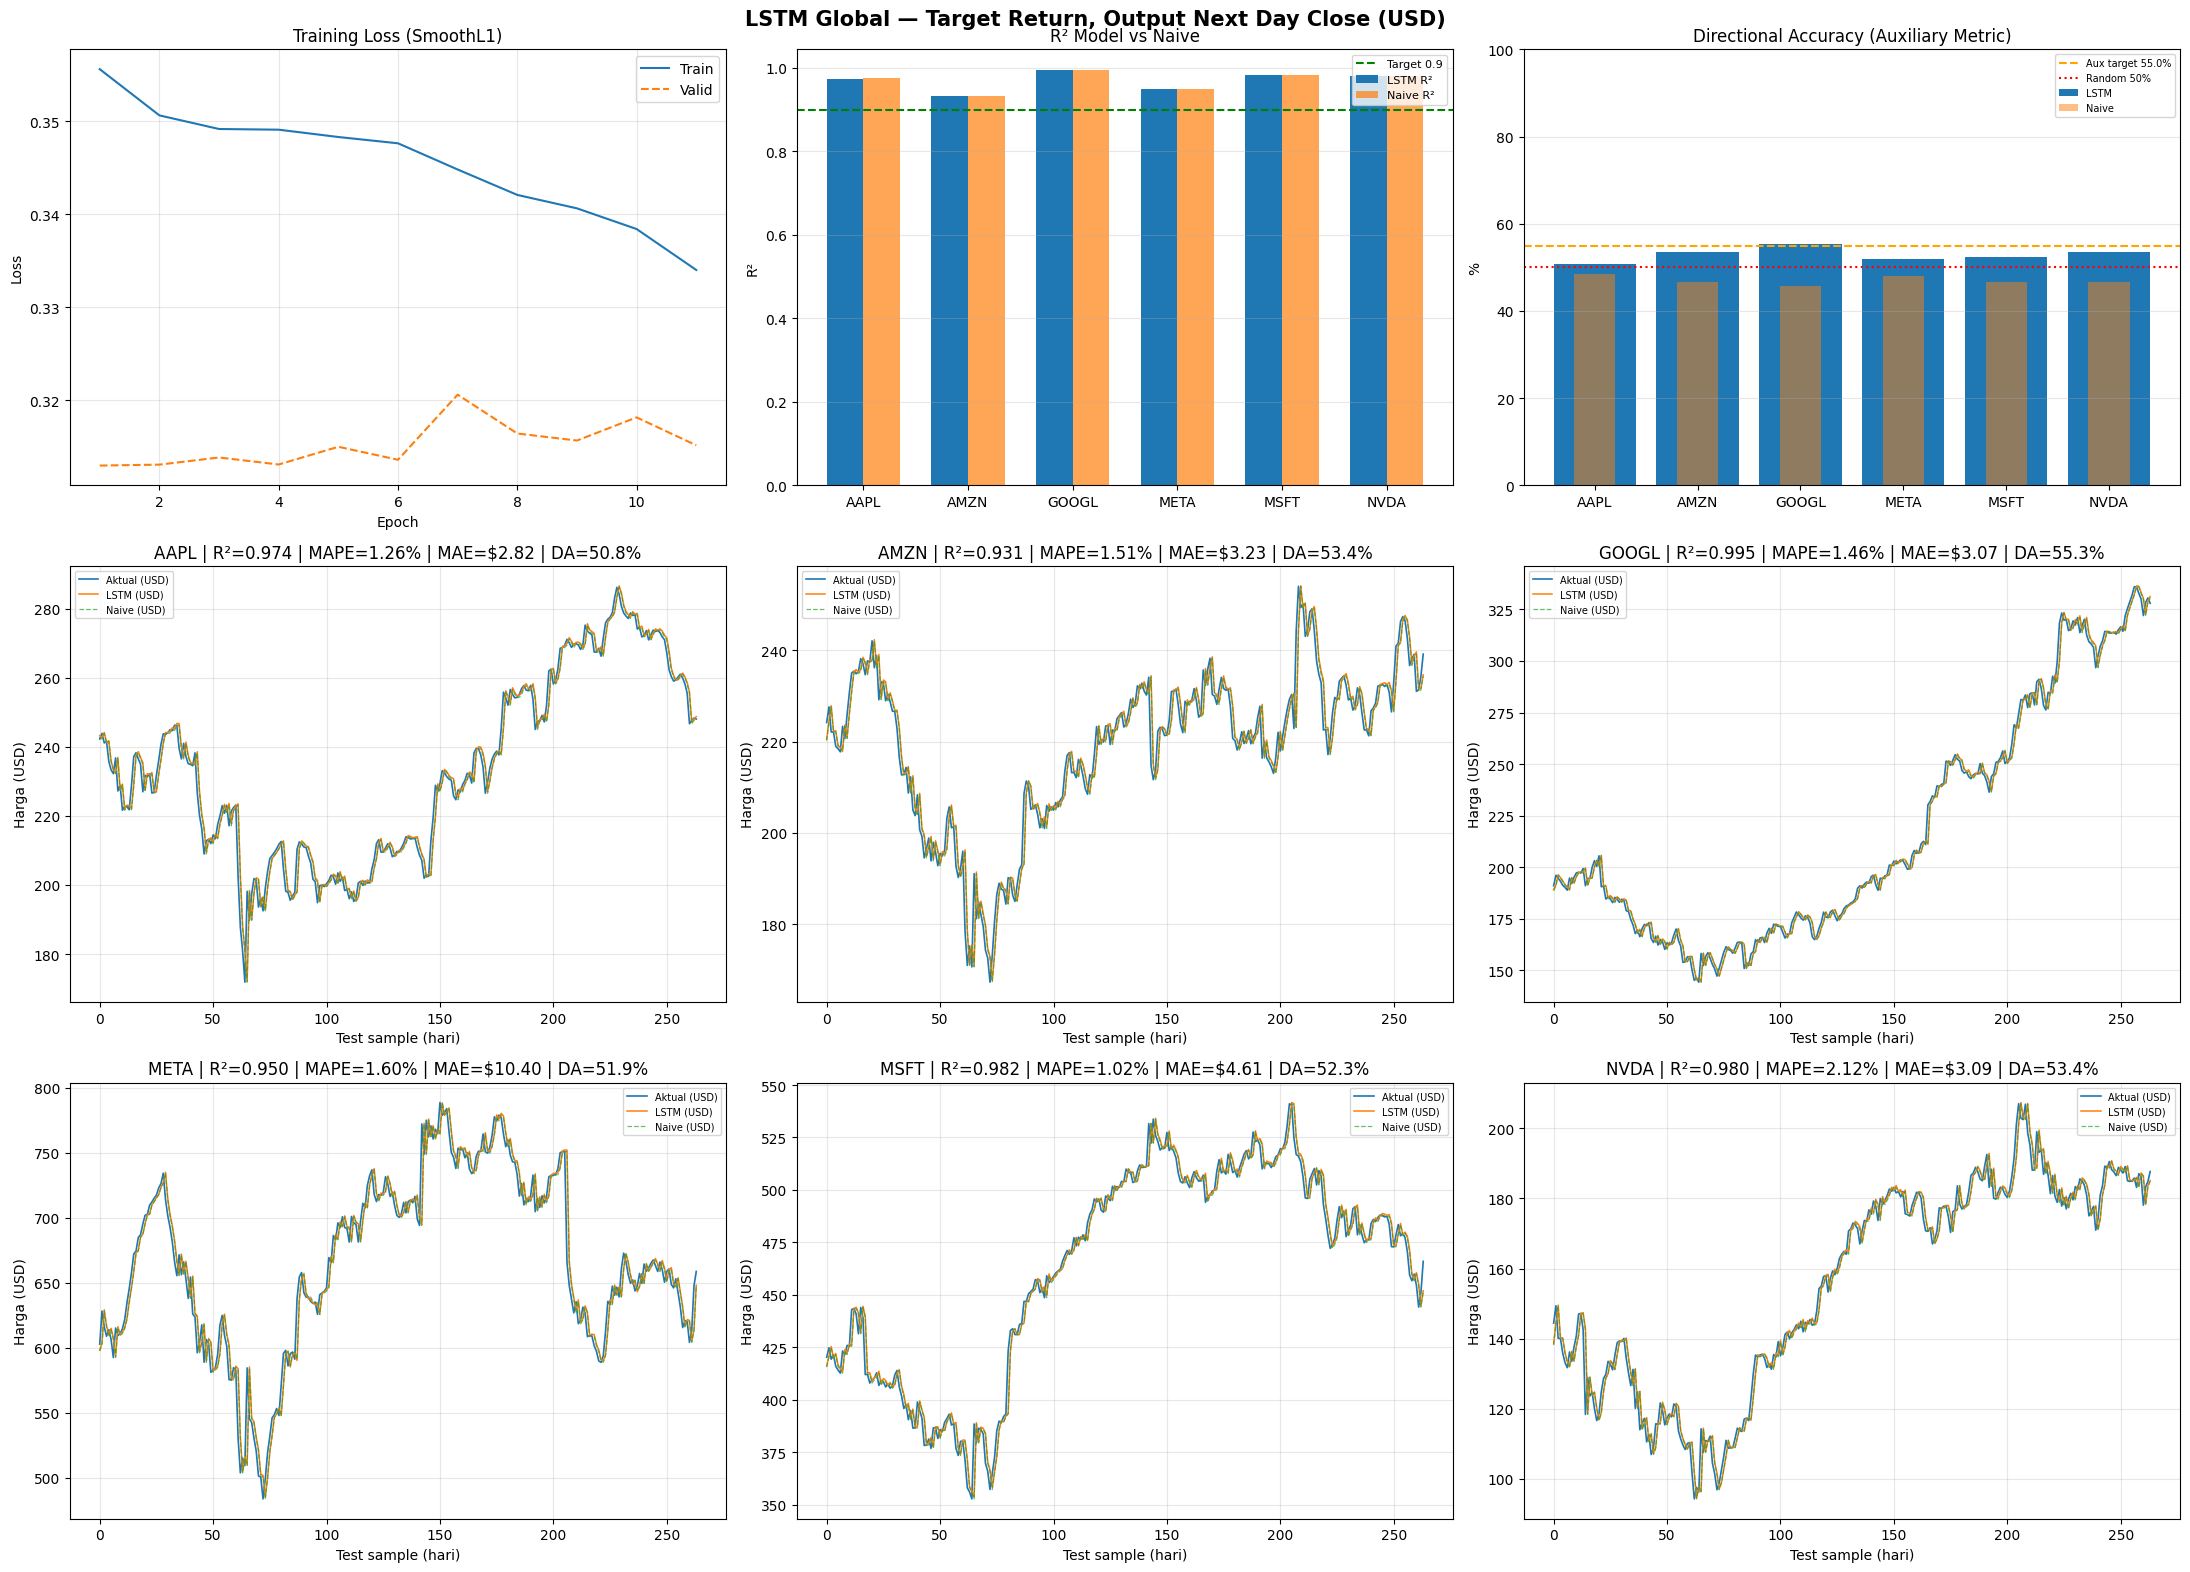

Gambar disimpan: lstm_global_outputs/lstm_global_evaluasi.png


In [ ]:
# VISUALIZATION
fig, axes = plt.subplots(3, 3, figsize=(22, 16))
fig.suptitle('LSTM Global — Target Return, Output Next Day Close (USD)',
             fontsize=15, fontweight='bold')

# Training loss
ax = axes[0, 0]
ax.plot(best_history['epoch'], best_history['train_loss'], label='Train')
ax.plot(best_history['epoch'], best_history['valid_loss'], label='Valid', linestyle='--')
ax.set_title('Training Loss (SmoothL1)'); ax.set_xlabel('Epoch')
ax.set_ylabel('Loss'); ax.grid(alpha=0.3); ax.legend()

# R2 model vs naive
ax = axes[0, 1]
plot_sum = summary[summary['Ticker'] != 'ALL'].copy()
x = np.arange(len(plot_sum)); w = 0.35
ax.bar(x-w/2, plot_sum['R2'],       width=w, label='LSTM R²')
ax.bar(x+w/2, plot_sum['R2_Naive'], width=w, label='Naive R²', alpha=0.7)
ax.axhline(TARGET_R2, color='green', linestyle='--', label=f'Target {TARGET_R2}')
ax.set_xticks(x); ax.set_xticklabels(plot_sum['Ticker'])
ax.set_title('R² Model vs Naive'); ax.set_ylabel('R²')
ax.grid(axis='y', alpha=0.3); ax.legend(fontsize=8)

# Directional Accuracy
ax = axes[0, 2]
ax.bar(plot_sum['Ticker'], plot_sum['Directional_Accuracy_%'], label='LSTM')
ax.bar(plot_sum['Ticker'], plot_sum['Naive_DA_%'], alpha=0.5, label='Naive', width=0.4)
ax.axhline(AUX_TARGET_DA, color='orange', linestyle='--', label=f'Aux target {AUX_TARGET_DA}%')
ax.axhline(50,             color='red',    linestyle=':',  label='Random 50%')
ax.set_title('Directional Accuracy (Auxiliary Metric)')
ax.set_ylabel('%'); ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3); ax.legend(fontsize=7)

# Actual vs predicted per ticker
tickers = sorted(best_detail['Ticker'].unique())
for i, ticker in enumerate(tickers):
    r, c = 1 + i // 3, i % 3
    ax = axes[r, c]
    g  = best_detail[best_detail['Ticker'] == ticker].reset_index(drop=True)
    ax.plot(g['Actual'].values,    label='Aktual (USD)',  linewidth=1.2)
    ax.plot(g['Predicted'].values, label='LSTM (USD)',    linewidth=1.1)
    ax.plot(g['Naive'].values,     label='Naive (USD)',   linewidth=0.9,
            linestyle='--', alpha=0.7)
    m = summary[summary['Ticker'] == ticker].iloc[0]
    ax.set_title(
        f"{ticker} | R²={m['R2']:.3f} | MAPE={m['MAPE_%']:.2f}% | "
        f"MAE=${m['MAE']:.2f} | DA={m['Directional_Accuracy_%']:.1f}%"
    )
    ax.set_xlabel('Test sample (hari)'); ax.set_ylabel('Harga (USD)')
    ax.grid(alpha=0.3); ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lstm_global_evaluasi.png', dpi=180, bbox_inches='tight')
plt.show()
print('Gambar disimpan:', OUTPUT_DIR / 'lstm_global_evaluasi.png')


## 12. Prediksi Terbaru

In [ ]:
# LATEST PREDICTIONS
latest = best_detail[best_detail['Date'] == best_detail['Date'].max()].copy()
latest['Pred_Change_%']   = (latest['Predicted'] / latest['Close'] - 1) * 100
latest['Actual_Change_%'] = (latest['Actual']    / latest['Close'] - 1) * 100
latest_out = latest[[
    'Date','Ticker','Close','Predicted','Actual',
    'Pred_Change_%','Actual_Change_%','APE_%','Dir_Correct','Beat_Naive'
]].sort_values('Ticker')
latest_out.to_excel(OUTPUT_DIR / 'lstm_global_latest_predictions.xlsx', index=False)

display(latest_out.round(4))
print('\nKeterangan kolom:')
print('  Close         : harga penutupan hari ini (USD)')
print('  Predicted     : prediksi harga besok (USD)')
print('  Actual        : harga besok aktual (USD)')
print('  Pred_Change_% : perubahan prediksi dari Close (%)')
print('  APE_%         : absolute percentage error prediksi vs aktual')
print('  Dir_Correct   : apakah arah prediksi benar (naik/turun)')
print('  Beat_Naive    : apakah LSTM lebih dekat ke aktual daripada naive')
print('\nSemua output tersimpan di:', OUTPUT_DIR)

,Date,Ticker,Close,Predicted,Actual,Pred_Change_%,Actual_Change_%,APE_%,Dir_Correct,Beat_Naive
263,2026-01-22,AAPL,248.35,248.7484,248.04,0.1604,-0.1248,0.2856,False,False
527,2026-01-22,AMZN,234.34,234.6187,239.16,0.1189,2.0568,1.8988,True,True
791,2026-01-22,GOOGL,330.54,331.2259,327.93,0.2075,-0.7896,1.0051,False,False
1055,2026-01-22,META,647.63,648.1351,658.76,0.0780,1.7186,1.6129,True,True
1319,2026-01-22,MSFT,451.14,451.9106,465.95,0.1708,3.2828,3.0131,True,True
1583,2026-01-22,NVDA,184.84,185.0844,187.67,0.1322,1.5311,1.3777,True,True



Keterangan kolom:
  Close         : harga penutupan hari ini (USD)
  Predicted     : prediksi harga besok (USD)
  Actual        : harga besok aktual (USD)
  Pred_Change_% : perubahan prediksi dari Close (%)
  APE_%         : absolute percentage error prediksi vs aktual
  Dir_Correct   : apakah arah prediksi benar (naik/turun)
  Beat_Naive    : apakah LSTM lebih dekat ke aktual daripada naive

Semua output tersimpan di: lstm_global_outputs
